Configuration loaded:
  Wavelength: 14.99 m
  Range resolution: 5.62 m
  Facets per position: 3000
  Time bins: 3600
COORDINATE SYSTEM TESTS

TEST 1: COORDINATE TRANSFORMATION ACCURACY
Testing coordinate transformations...
  Input:  (  0.00,   0.00,     0.0)
  Output: (  0.00,   0.00,     0.0)
  Errors: (0.0000°, 0.0000°,   0.00 m)
  Input:  ( 45.00,  90.00,  1000.0)
  Output: ( 45.00,  90.00,  1000.0)
  Errors: (0.0000°, 0.0000°,   0.00 m)
  Input:  (-45.00, 180.00, -2000.0)
  Output: (-45.00, 180.00, -2000.0)
  Errors: (0.0000°, 0.0000°,   0.00 m)
  Input:  ( 85.00, 270.00,  5000.0)
  Output: ( 85.00, 270.00,  5000.0)
  Errors: (0.0000°, 0.0000°,   0.00 m)
✓ All coordinate transform tests passed!

Testing local coordinate frame...
  Along-track:  [0. 1. 0.]
  Cross-track:  [ 0.  0. -1.]
  Vertical:     [1. 0. 0.]
✓ Local frame test passed!

TEST 2: MARS ELLIPSOID VISUALIZATION

✓ Ellipsoid plot saved: outputs/test_mars_ellipsoid.png


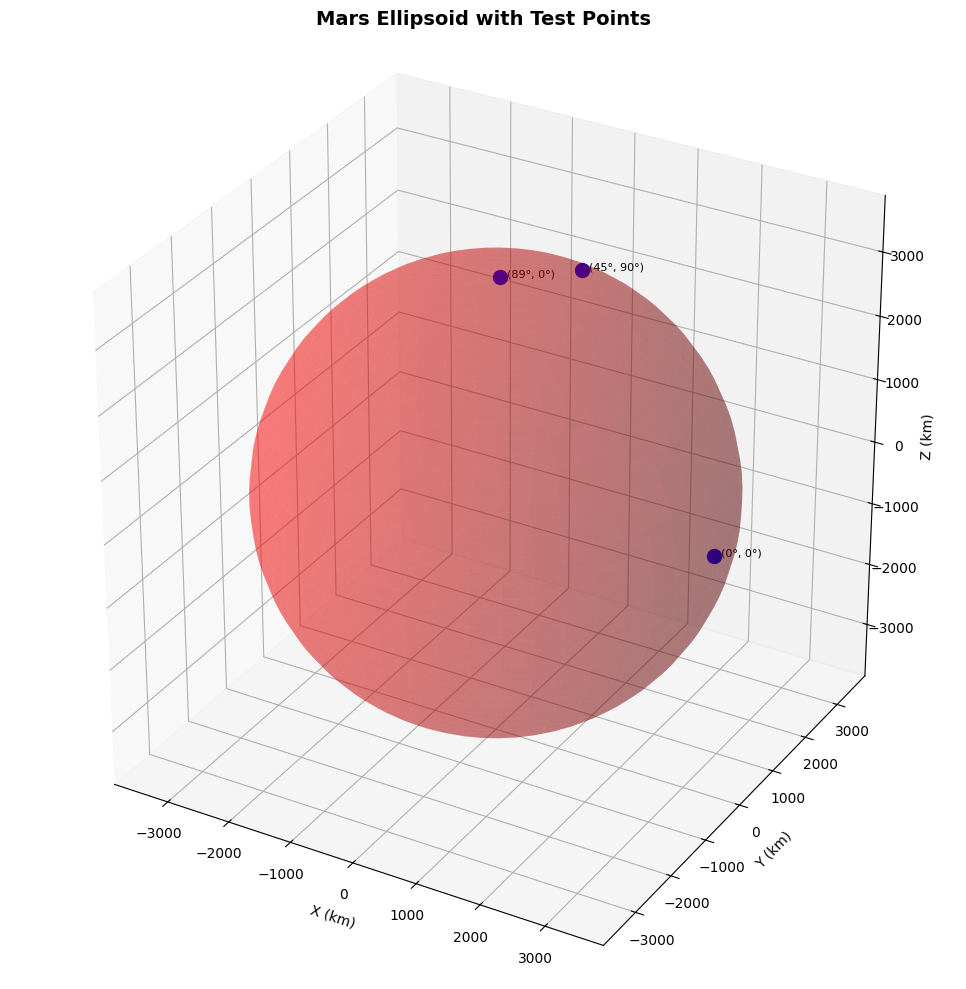


TEST 3: CROSS-TRACK COORDINATE SYSTEM

Nadir position: (-42.0°, 105.0°)
Spacecraft altitude: 300.0 km

Local frame vectors:
  Along-track:  [-0.96592583 -0.25881905  0.        ]
  Cross-track:  [ 0.17205225 -0.64210775 -0.747058  ]
  Vertical:     [-0.19335284  0.72160262 -0.66475886]

Test points at various cross-track distances:
  d_c =  -45.0 km → computed =  -45.0 km
       Position: (-41.238°, 105.000°)
  d_c =  -20.0 km → computed =  -20.0 km
       Position: (-41.661°, 105.000°)
  d_c =    0.0 km → computed =    0.0 km
       Position: (-42.000°, 105.000°)
  d_c =   20.0 km → computed =   20.0 km
       Position: (-42.339°, 105.000°)
  d_c =   45.0 km → computed =   45.0 km
       Position: (-42.762°, 105.000°)

✓ Cross-track system working correctly!

TEST 4: RANGE AND INCIDENCE ANGLE CALCULATIONS

Facet properties:
  Area: 900.00 m²  (expected ~900.00 m²)
  Normal: [-0.19335284  0.72160262 -0.66475886]

Geometric calculations:
  Range: 300.000 km  (expected ~300 km)
  Inciden

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
sys.path.append('../src')

from coordinates import *
import config

print("="*70)
print("COORDINATE SYSTEM TESTS")
print("="*70)

# ============================================================================
# TEST 1: Run built-in tests
# ============================================================================

print("\n" + "="*70)
print("TEST 1: COORDINATE TRANSFORMATION ACCURACY")
print("="*70)

test_coordinate_transforms()
test_local_frame()

# ============================================================================
# TEST 2: Visualize Mars ellipsoid
# ============================================================================

print("\n" + "="*70)
print("TEST 2: MARS ELLIPSOID VISUALIZATION")
print("="*70)

# Create ellipsoid surface
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(-np.pi/2, np.pi/2, 50)
u_grid, v_grid = np.meshgrid(u, v)

# Parametric ellipsoid
a = config.MARS_EQUATORIAL_RADIUS / 1000  # Convert to km for visualization
b = config.MARS_POLAR_RADIUS / 1000

x = a * np.cos(v_grid) * np.cos(u_grid)
y = a * np.cos(v_grid) * np.sin(u_grid)
z = b * np.sin(v_grid)

# Plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z, alpha=0.3, color='red', edgecolor='none')

# Add some test points
test_points = [
    (0, 0, 0),      # Equator
    (45, 90, 0),    # Mid-latitude
    (89, 0, 0),     # Near pole
]

for lat, lon, h in test_points:
    X, Y, Z = geodetic_to_mbfc(lat, lon, h)
    X_km, Y_km, Z_km = X/1000, Y/1000, Z/1000
    ax.scatter(X_km, Y_km, Z_km, s=100, c='blue')
    ax.text(X_km, Y_km, Z_km, f'  ({lat}°, {lon}°)', fontsize=8)

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('Mars Ellipsoid with Test Points', fontsize=14, fontweight='bold')
ax.set_box_aspect([1,1,b/a])  # Equal aspect ratio

plt.tight_layout()
plt.savefig('../data/outputs/test_mars_ellipsoid.png', dpi=150)
print("\n✓ Ellipsoid plot saved: outputs/test_mars_ellipsoid.png")
plt.show()

# ============================================================================
# TEST 3: Cross-track coordinate system
# ============================================================================

print("\n" + "="*70)
print("TEST 3: CROSS-TRACK COORDINATE SYSTEM")
print("="*70)

# Simulate spacecraft on orbit
lat_nadir = -42.0  # Eastern Hellas latitude
lon_nadir = 105.0
h_nadir = 0.0

# Spacecraft 300 km above
X_n, Y_n, Z_n = geodetic_to_mbfc(lat_nadir, lon_nadir, h_nadir)
nadir_pos = np.array([X_n, Y_n, Z_n])

# Spacecraft directly above (simplified)
spacecraft_pos = nadir_pos * (1 + 300000 / np.linalg.norm(nadir_pos))

# Velocity (tangent to orbit, roughly eastward)
velocity = np.array([-Y_n, X_n, 0])  # Perpendicular to radial
velocity = velocity / np.linalg.norm(velocity) * 3000  # 3 km/s

# Compute local frame
A_hat, C_hat, Z_hat = compute_local_frame(spacecraft_pos, nadir_pos, velocity)
print("Dot products:")
print("A·Z =", np.dot(A_hat, Z_hat))
print("C·Z =", np.dot(C_hat, Z_hat))
print("A·C =", np.dot(A_hat, C_hat))

print(f"\nNadir position: ({lat_nadir}°, {lon_nadir}°)")
print(f"Spacecraft altitude: {np.linalg.norm(spacecraft_pos - nadir_pos)/1000:.1f} km")
print(f"\nLocal frame vectors:")
print(f"  Along-track:  {A_hat}")
print(f"  Cross-track:  {C_hat}")
print(f"  Vertical:     {Z_hat}")

# Test points at various cross-track distances
cross_track_distances = [-45000, -20000, 0, 20000, 45000]  # meters

print(f"\nTest points at various cross-track distances:")
for d_c in cross_track_distances:
    # Point at distance d_c from nadir in cross-track direction
    point = nadir_pos + d_c * C_hat
    
    # Verify cross-track distance calculation
    d_c_computed = cross_track_distance(point, nadir_pos, C_hat)
    
    # Convert back to geodetic
    lat, lon, h = mbfc_to_geodetic(point[0], point[1], point[2])
    
    print(f"  d_c = {d_c/1000:6.1f} km → computed = {d_c_computed/1000:6.1f} km")
    print(f"       Position: ({lat:7.3f}°, {lon:7.3f}°)")
    
    # Check accuracy
    assert abs(d_c - d_c_computed) < 1.0, f"Cross-track distance error: {abs(d_c - d_c_computed)} m"

print("\n✓ Cross-track system working correctly!")

# ============================================================================
# TEST 4: Geometric calculations
# ============================================================================

print("\n" + "="*70)
print("TEST 4: RANGE AND INCIDENCE ANGLE CALCULATIONS")
print("="*70)

# Create a simple facet (flat, horizontal at nadir)
facet_size = 30.0  # meters
offsets = np.array([
    [-facet_size/2, -facet_size/2, 0],
    [+facet_size/2, -facet_size/2, 0],
    [+facet_size/2, +facet_size/2, 0],
    [-facet_size/2, +facet_size/2, 0],
])

# Place corners around nadir (in local ENU frame, then transform)
corners = []
for offset in offsets:
    # Create point in local frame
    point_local = offset[0] * C_hat + offset[1] * A_hat + offset[2] * Z_hat
    point_global = nadir_pos + point_local
    corners.append(point_global)

c1, c2, c3, c4 = corners

# Compute facet properties
normal = compute_surface_normal(c1, c2, c3, c4)
area = compute_facet_area(c1, c2, c3, c4)
center = (c1 + c2 + c3 + c4) / 4.0

print(f"\nFacet properties:")
print(f"  Area: {area:.2f} m²  (expected ~{facet_size**2:.2f} m²)")
print(f"  Normal: {normal / np.linalg.norm(normal)}")

# Compute range and incidence angle
range_m = compute_range(spacecraft_pos, center)
inc_angle, cos_inc = compute_incidence_angle(spacecraft_pos, center, normal)

print(f"\nGeometric calculations:")
print(f"  Range: {range_m/1000:.3f} km  (expected ~300 km)")
print(f"  Incidence angle: {inc_angle:.2f}°  (expected ~0° for nadir)")
print(f"  cos(incidence): {cos_inc:.6f}  (expected ~1.0)")

# Sanity checks
assert abs(area - facet_size**2) < 10, "Area calculation error"
assert abs(range_m - 300000) < 1000, "Range calculation error"
assert inc_angle < 5.0, "Incidence angle should be small for nadir facet"

print("\n✓ Geometric calculations working correctly!")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("ALL COORDINATE TESTS PASSED ✓")
print("="*70)
print("\nReady to proceed to Section 3: DEM Processing & Interpolation")